In [1]:
# Tools

from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [ ]:
#TOOL CREATION

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
Arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query Arxiv content")
print(Arxiv.name)

arxiv


In [3]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [4]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["Tavily_API_Key"]=os.getenv("Tavily_API_Key")
os.environ["Groq_API_Key"]=os.getenv("Groq_API_Key")

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily=TavilySearchResults()
tavily.invoke("what is latest News in AI?")

C:\Users\NANDANA\AppData\Local\Temp\ipykernel_20256\4020428212.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


[{'title': 'Agentic AI News + AI Breakthroughs + AI Developments | 2026 | News',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Date: January 5, 2026\n\nSummary: During its CES 2026 keynote, NVIDIA officially unveiled its latest flagship AI platform, codenamed "Vera Rubin." Following the Blackwell architecture, the Rubin platform introduces radical improvements in processing power and memory bandwidth, specifically engineered to handle the massive scaling requirements of trillion-parameter models. Named after the pioneering astronomer, the architecture features the new H300 GPUs and a dedicated AI foundry for custom silicon, signaling NVIDIA\'s intent to maintain its dominant lead in the global AI hardware race. The platform is expected to enter full production later this year to support the next wave of sovereign and enterprise AI infrastructure.\n\nSource: Yahoo Finance ↗ [...] Date: March 3, 2026\n\nSummary: Oracle announced plans to cut 20,000–30

In [6]:
# COMBILE ALL TOOLS IN LIST

tools=[Arxiv,wiki,tavily]

In [7]:
#Intialize LLM model

from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("what is AI")

AIMessage(content='AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of developing algorithms that enable machines to process and analyze large amounts of data, identify patterns, and make decisions based on that data. The primary goal of AI is to create intelligent systems that can perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI can learn from experience, adjust to new data, and improve its performance over time.\n2. **Problem-solving**: AI can identify problems, analyze data, and develop solutions using reasoning and logic.\n3. **Perception**: AI can interpret and understand data from sensors, such as images, speech, and text.\n4. **Reasoning**: AI can draw conclusions, make infer

In [8]:
#Combine tools with LLM

llm_with_tools=llm.bind_tools(tools=tools)

# Execute this call

llm_with_tools.invoke("what is the recent news in AI")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pm7j2y3ng', 'function': {'arguments': '{"query":"recent news in AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 460, 'total_tokens': 481, 'completion_time': 0.033533105, 'completion_tokens_details': None, 'prompt_time': 0.032060396, 'prompt_tokens_details': None, 'queue_time': 0.052689762, 'total_time': 0.065593501}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2194-e3ba-7742-aad5-1956e5bbd66e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news in AI'}, 'id': 'pm7j2y3ng', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 460, 'output_tokens': 21, 'total_tokens': 481})

This means it knows if LLm is making specific request based on the tool .It does not directly give o/p.Output will be given by langgraph

In [ ]:
#Workflow

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage#AI /human message
from typing import Annotated # Labelling
from langgraph.graph.message import add_messages #Reducer in Langgraph
# add_messages is reducer ,which means it does not overwrite,it will keep on getting appended

In [10]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [11]:
#Entire chatbot with Langgraph

from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage

In [12]:
#Node definition

def tool_calling_llm(state:State):
    return{"messages":llm_with_tools.invoke(state["messages"])}


In [13]:
#Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [ ]:
# Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)
#If the latest message(result) from Assistant is a tool call->tool condition routes to tools
#If the latest message(result) from Assistant is not from a tool call->tool condition routes to END

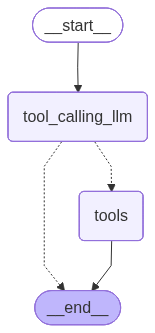

In [15]:
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages=graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (yn7py020r)
 Call ID: yn7py020r
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
